# v1_0 Flop C-Bet Strategy by Board Texture 

## Table of Contents

1. [Introduction](#Introduction)
1. [Load and Validate Data](#Dataset-Inspection)  
2. [Pool Overview](#Pool-Overview)  
3. [Texture Prevalence](#Texture-Prevalence)  
4. [Main Strategy Analysis](#Main-Strategy-Analysis)  


## Introduction

This study examines flop continuation-bet strategy in single-raised pots (SRPs) using hand-history data stored in a PokerTracker 4 PostgreSQL database. The focus of version 1 is to analyze how flop c-bet behavior varies by board texture across pooled 2nl, 5nl, and 10nl data.

The main strategy question is split into two related components: how often the pool continuation-bets on a given texture, and how the pool distributes its c-bet sizings once it chooses to bet. Board texture is defined using pairedness and suitedness, while the final grouped strategy outputs are segmented by blind level, relative position, and heads-up versus multiway flop context.

In addition to the main strategy table, the analysis also includes supporting pool-overview and texture-frequency outputs to provide context for sample composition and the practical weight of each texture class. Together, these outputs are intended to establish a clean first research layer that can later be extended with refined texture definitions, additional preflop action trees, and later-street analysis.

Inputs: 
- 01_pool_overview
- 02_flop_cbet_strategy_by_texture
- 03_texture_frequency

In [1]:
import sys
print(sys.executable)

/Users/royguo/Desktop/MyProjects/NLHE_Data_Research/.venv/bin/python


## Import Required Libraries

In [ ]:
# Import Packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# from scipy import stats


## Dataset Inspection 

This step inspects the data we are working with to ensure our database queries produced the expected outputs, as well as the dimensions of the dataset. 

In [ ]:
# Load Datasets

pool_overview = pd.read_csv("../../results/v1_0/01_pool_overview.csv")
cbet_strategy = pd.read_csv("../../results/v1_0/02_flop_cbet_strategy_by_texture.csv")
texture_freq = pd.read_csv("../../results/v1_0/03_texture_frequency.csv")

In [4]:
# Verify Data

for name, df in {
    "pool_overview": pool_overview,
    "cbet_strategy": cbet_strategy,
    "texture_freq": texture_freq,
}.items():
    print(name, df.shape)
    print(df.head(), "\n")

pool_overview (16, 7)
   bb_size pf_action  number_hands  pct_hands_see_flop  avg_players_to_flop  \
0     0.02       All        130050              0.5042                 2.30   
1     0.02       SRP         76865              0.5247                 2.27   
2     0.02       3BP         15102              0.5825                 2.17   
3     0.02      4BP+          2621              0.6150                 2.08   
4     0.05       All         42082              0.4931                 2.30   

   pct_flop_hu  pct_flop_mw  
0       0.7476       0.2524  
1       0.7676       0.2324  
2       0.8512       0.1488  
3       0.9206       0.0794  
4       0.7499       0.2501   

cbet_strategy (72, 12)
   bb_size player_bucket relative_position pairedness suitedness  \
0     0.02            HU                IP     Paired      2Tone   
1     0.02            HU                IP     Paired    Rainbow   
2     0.02            HU                IP      Trips    Rainbow   
3     0.02            HU  

## Pool Overview

This section describes the analyzed player pool by stake and preflop action, including hand counts, flop-seen rates, average player to flop, and heads-up (HU) vs multi-way (MW) flop composition. 

In [5]:
# Inspect pool_overview dataset
pool_overview.head()

,bb_size,pf_action,number_hands,pct_hands_see_flop,avg_players_to_flop,pct_flop_hu,pct_flop_mw
0,0.02,All,130050,0.5042,2.30,0.7476,0.2524
1,0.02,SRP,76865,0.5247,2.27,0.7676,0.2324
2,0.02,3BP,15102,0.5825,2.17,0.8512,0.1488
3,0.02,4BP+,2621,0.6150,2.08,0.9206,0.0794
4,0.05,All,42082,0.4931,2.30,0.7499,0.2501


In [6]:
# Check dataset dimensions
pool_overview.shape

(16, 7)

In [7]:
# Check data types
pool_overview.dtypes

bb_size                float64
pf_action                  str
number_hands             int64
pct_hands_see_flop     float64
avg_players_to_flop    float64
pct_flop_hu            float64
pct_flop_mw            float64
dtype: object

In [8]:
# Display percentages in a more readable format (e.g., 0.25 -> 25.00%)

pool_overview_display = pool_overview.copy()

pct_cols = ["pct_hands_see_flop", "pct_flop_hu", "pct_flop_mw"]
for col in pct_cols:
    pool_overview_display[col] = (pool_overview_display[col] * 100).round(2)

pool_overview_display.head()

,bb_size,pf_action,number_hands,pct_hands_see_flop,avg_players_to_flop,pct_flop_hu,pct_flop_mw
0,0.02,All,130050,50.42,2.30,74.76,25.24
1,0.02,SRP,76865,52.47,2.27,76.76,23.24
2,0.02,3BP,15102,58.25,2.17,85.12,14.88
3,0.02,4BP+,2621,61.50,2.08,92.06,7.94
4,0.05,All,42082,49.31,2.30,74.99,25.01


In [9]:
pool_all = pool_overview_display[pool_overview_display["pf_action"] == "All"].copy()
pool_all

,bb_size,pf_action,number_hands,pct_hands_see_flop,avg_players_to_flop,pct_flop_hu,pct_flop_mw
0,0.02,All,130050,50.42,2.30,74.76,25.24
4,0.05,All,42082,49.31,2.30,74.99,25.01
8,0.10,All,54340,64.77,2.41,66.05,33.95
12,0.30,All,12953,57.88,2.36,70.01,29.99


In [10]:
# Compare frequencies across different bet sizes for each preflop action category
pf_order = {"SRP": 0, "3BP": 1, "4BP+": 2}

pool_breakdown = (
    pool_overview_display[pool_overview_display["pf_action"] != "All"]
    .assign(pf_sort=lambda df: df["pf_action"].map(pf_order))
    .sort_values(["pf_sort", "bb_size"])
    .drop(columns="pf_sort")
    .reset_index(drop=True)
)

pool_breakdown

,bb_size,pf_action,number_hands,pct_hands_see_flop,avg_players_to_flop,pct_flop_hu,pct_flop_mw
0,0.02,SRP,76865,52.47,2.27,76.76,23.24
1,0.05,SRP,24733,51.24,2.26,77.56,22.44
2,0.10,SRP,29549,64.32,2.37,68.42,31.58
3,0.30,SRP,7284,59.77,2.34,71.70,28.30
4,0.02,3BP,15102,58.25,2.17,85.12,14.88
5,0.05,3BP,5507,54.95,2.15,85.99,14.01
6,0.10,3BP,4386,68.92,2.23,79.42,20.58
7,0.30,3BP,1280,63.67,2.20,80.86,19.14
8,0.02,4BP+,2621,61.50,2.08,92.06,7.94
9,0.05,4BP+,1015,55.86,2.07,92.77,7.23


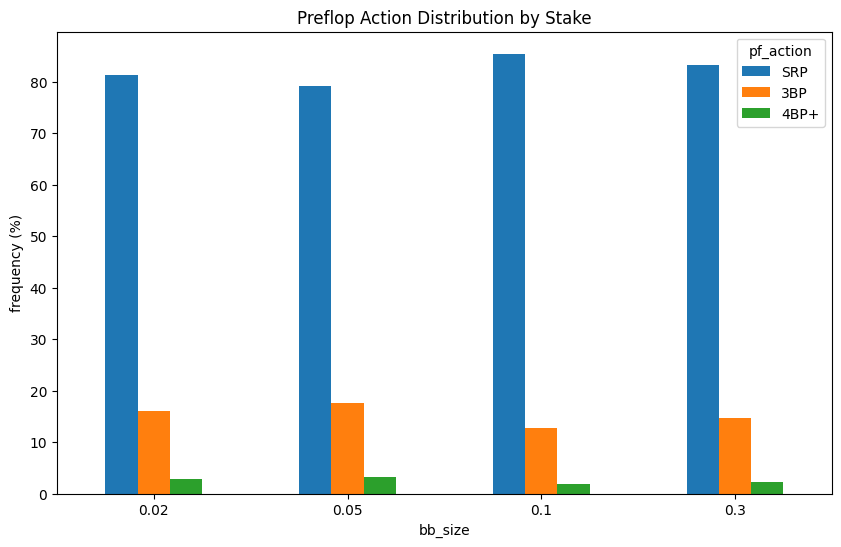

In [ ]:
# Visualize the distribution of preflop actions across different bet sizes

pool_pf = pool_overview[pool_overview["pf_action"] != "All"].copy()

pivot_pf = pool_pf.pivot(
    index="bb_size",
    columns="pf_action",
    values="number_hands"
)

pivot_pf_pct = pivot_pf.div(pivot_pf.sum(axis=1), axis=0) * 100

sorted_cols = pivot_pf_pct.mean(axis=0).sort_values(ascending=False).index
pivot_pf_pct = pivot_pf_pct[sorted_cols]

pivot_pf_pct.plot(kind="bar", figsize=(10, 6))
plt.title("Preflop Action Distribution by Stake")
plt.xlabel("bb_size")
plt.ylabel("frequency (%)")
plt.xticks(rotation=0)
plt.legend(title="pf_action")
plt.show()

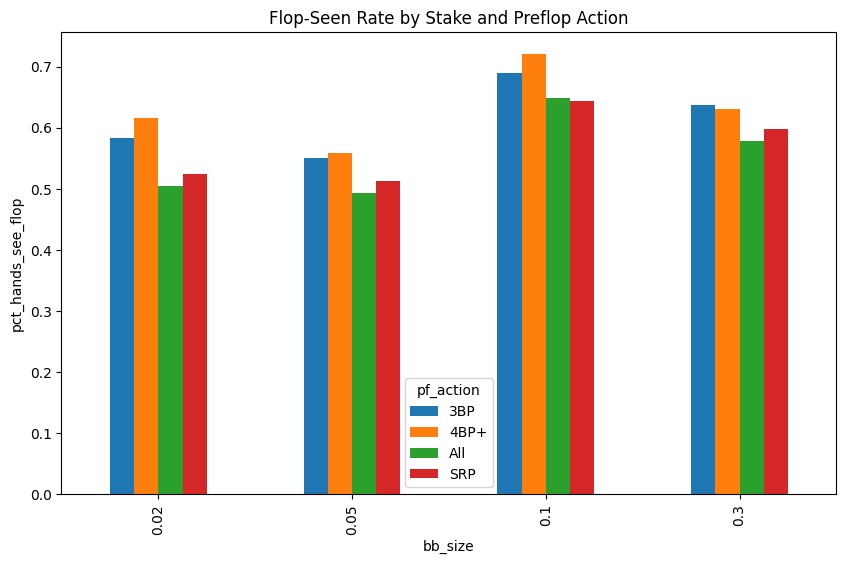

In [12]:
# Plot the percentage of hands that see the flop by stake and preflop action
pivot_flop_seen = pool_overview.pivot(
    index="bb_size",
    columns="pf_action",
    values="pct_hands_see_flop"
)

pivot_flop_seen.plot(kind="bar", figsize=(10, 6))
plt.ylabel("pct_hands_see_flop")
plt.title("Flop-Seen Rate by Stake and Preflop Action")
plt.legend(title="pf_action")
plt.show()

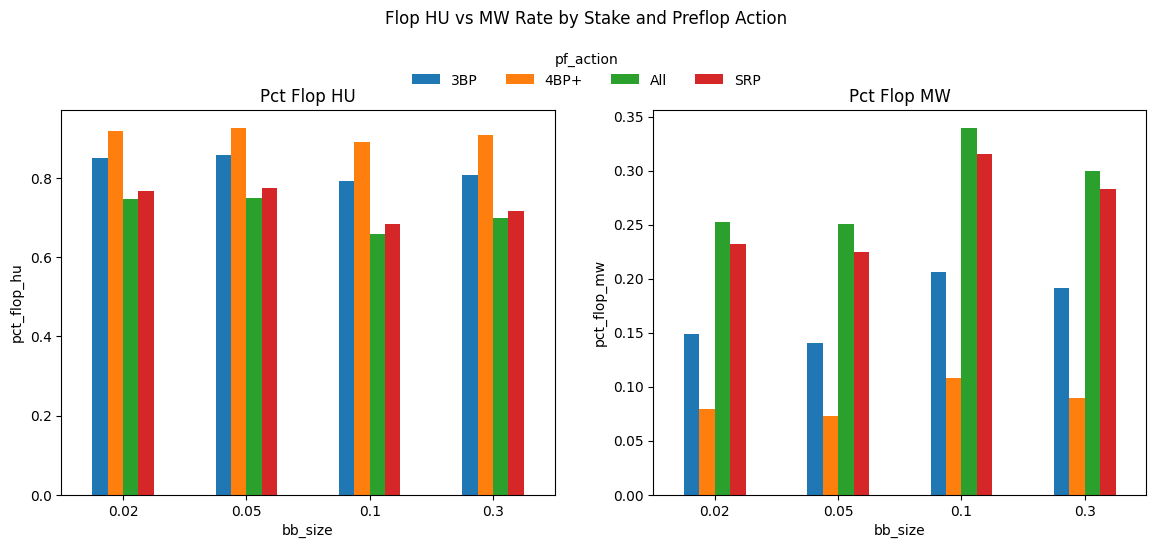

In [13]:
# Plot the percentage of hands that see the flop by stake and preflop action, separating HU and MW

pivot_hu = pool_overview.pivot(index="bb_size", columns="pf_action", values="pct_flop_hu")
pivot_mw = pool_overview.pivot(index="bb_size", columns="pf_action", values="pct_flop_mw")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pivot_hu.plot(kind="bar", ax=axes[0], legend=False)
axes[0].set_title("Pct Flop HU")
axes[0].set_ylabel("pct_flop_hu")
axes[0].tick_params(axis="x", rotation=0)

pivot_mw.plot(kind="bar", ax=axes[1], legend=False)
axes[1].set_title("Pct Flop MW")
axes[1].set_ylabel("pct_flop_mw")
axes[1].tick_params(axis="x", rotation=0)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="pf_action",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=4,
    frameon=False
)

fig.suptitle("Flop HU vs MW Rate by Stake and Preflop Action", y=1.08)
plt.show()

## Texture Prevalence 

This section examines how often each board texture, defined by pairedness and suitedness, occurs within the SRP flop c-bet opportunity sample. Texture prevalence provides important context for the main strategy results by showing how much practical weight each texture class carried in the unerlying data. 

In [14]:
# Inspect cbet_strategy dataset
texture_freq.head()

,bb_size,num_players,pairedness,suitedness,occurrences,total_flops,texture_frequency
0,0.02,HU,Paired,2Tone,2361,28351,0.0833
1,0.02,HU,Paired,Rainbow,2435,28351,0.0859
2,0.02,HU,Trips,Rainbow,65,28351,0.0023
3,0.02,HU,Unpaired,2Tone,13043,28351,0.4601
4,0.02,HU,Unpaired,Monotone,1486,28351,0.0524


In [15]:
# Check dataset dimensions
texture_freq.shape

(36, 7)

In [16]:
# Check data types
texture_freq.dtypes

bb_size              float64
num_players              str
pairedness               str
suitedness               str
occurrences            int64
total_flops            int64
texture_frequency    float64
dtype: object

In [17]:
# Define sorting orders for categorical variables and convert frequencies to percentages 

paired_order = {"Unpaired": 0, "Paired": 1, "Trips": 2}
suited_order = {"Rainbow": 0, "Two-Tone": 1, "Monotone": 2}
num_players_order = {"HU": 0, "MW": 1}

texture_freq_display = texture_freq.copy()
texture_freq_display["texture_frequency"] = (texture_freq_display["texture_frequency"] * 100).round(2)

texture_freq_display = (
    texture_freq_display
    .assign(
        paired_sort=lambda df: df["pairedness"].map(paired_order),
        suited_sort=lambda df: df["suitedness"].map(suited_order),
        players_sort=lambda df: df["num_players"].map(num_players_order)
    )
    .sort_values(["bb_size", "players_sort", "paired_sort", "suited_sort"])
    .drop(columns=["paired_sort", "suited_sort", "players_sort"])
    .reset_index(drop=True)
)

texture_freq_display

,bb_size,num_players,pairedness,suitedness,occurrences,total_flops,texture_frequency
0,0.02,HU,Unpaired,Rainbow,8961,28351,31.61
1,0.02,HU,Unpaired,Monotone,1486,28351,5.24
2,0.02,HU,Unpaired,2Tone,13043,28351,46.01
3,0.02,HU,Paired,Rainbow,2435,28351,8.59
4,0.02,HU,Paired,2Tone,2361,28351,8.33
5,0.02,HU,Trips,Rainbow,65,28351,0.23
6,0.02,MW,Unpaired,Rainbow,2392,7724,30.97
7,0.02,MW,Unpaired,Monotone,382,7724,4.95
8,0.02,MW,Unpaired,2Tone,3574,7724,46.27
9,0.02,MW,Paired,Rainbow,707,7724,9.15


In [18]:
# Aggregate frequencies by bb_size, pairedness, and suitedness to get total occurrences for each texture category

texture_freq_bb = (
    texture_freq
    .groupby(["bb_size", "pairedness", "suitedness"], as_index=False)["occurrences"]
    .sum()
)

texture_freq_bb["total_flops"] = texture_freq_bb.groupby("bb_size")["occurrences"].transform("sum")
texture_freq_bb["texture_frequency"] = (
    texture_freq_bb["occurrences"] / texture_freq_bb["total_flops"]
)

texture_freq_bb.head()

,bb_size,pairedness,suitedness,occurrences,total_flops,texture_frequency
0,0.02,Paired,2Tone,3007,36075,0.083354
1,0.02,Paired,Rainbow,3142,36075,0.087096
2,0.02,Trips,Rainbow,88,36075,0.002439
3,0.02,Unpaired,2Tone,16617,36075,0.460624
4,0.02,Unpaired,Monotone,1868,36075,0.051781


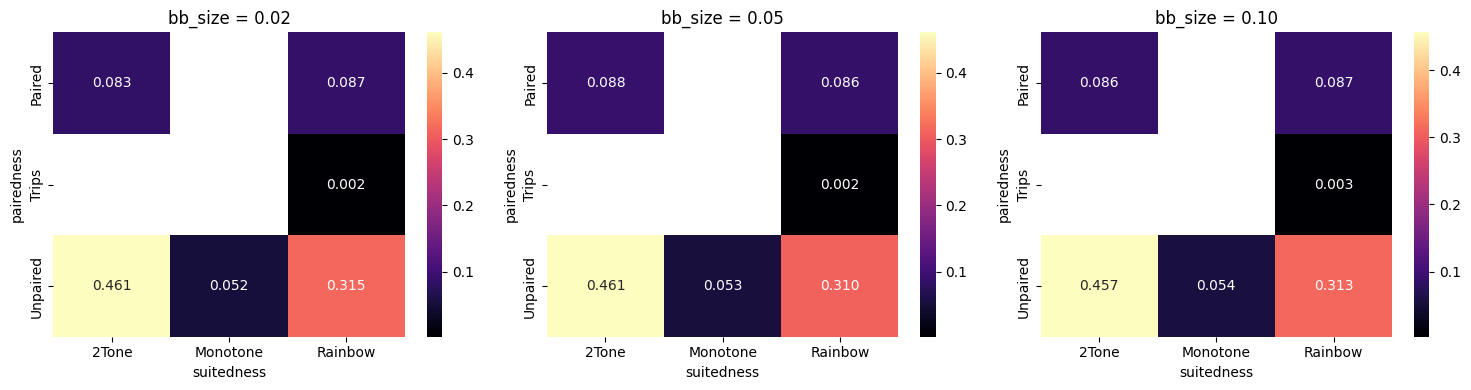

In [68]:
# Visualize the distribution of texture frequencies across different bet sizes using heatmaps

stakes = sorted(texture_freq_bb["bb_size"].unique())

fig, axes = plt.subplots(1, len(stakes), figsize=(15, 4))

for ax, stake in zip(axes, stakes):
    heatmap_df = (
        texture_freq_bb[texture_freq_bb["bb_size"] == stake]
        .pivot(index="pairedness", columns="suitedness", values="texture_frequency")
    )
    
    sns.heatmap(heatmap_df, annot=True, fmt=".3f", cmap="magma",  ax=ax) 
    ax.set_title(f"bb_size = {stake:.2f}")

plt.tight_layout()
plt.show()

In [ ]:
# Calculate Wilson confidence intervals for texture frequencies to understand the uncertainty around these estimates

def wilson_ci(k, n, z=1.96):
    if n == 0:
        return (np.nan, np.nan)
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    margin = z * np.sqrt((p * (1 - p) / n) + (z**2 / (4 * n**2))) / denom
    return center - margin, center + margin

texture_freq_all = (
    texture_freq
    .groupby(["pairedness", "suitedness"], as_index=False)["occurrences"]
    .sum()
)

texture_freq_all["total_flops"] = texture_freq_all["occurrences"].sum()
texture_freq_all["texture_frequency"] = (
    texture_freq_all["occurrences"] / texture_freq_all["total_flops"]
)

texture_freq_all[["ci_low", "ci_high"]] = texture_freq_all.apply(
    lambda row: pd.Series(wilson_ci(row["occurrences"], row["total_flops"])),
    axis=1
)

texture_freq_all["freq_pct"] = texture_freq_all["texture_frequency"] * 100
texture_freq_all["ci_low_pct"] = texture_freq_all["ci_low"] * 100
texture_freq_all["ci_high_pct"] = texture_freq_all["ci_high"] * 100

texture_freq_all = texture_freq_all.sort_values("texture_frequency", ascending=False)
texture_freq_all

,pairedness,suitedness,occurrences,total_flops,texture_frequency,ci_low,ci_high,freq_pct,ci_low_pct,ci_high_pct
3,Unpaired,2Tone,29609,64401,0.459760,0.455913,0.463611,45.975994,45.591327,46.361141
5,Unpaired,Rainbow,20185,64401,0.313427,0.309855,0.317021,31.342681,30.985524,31.702064
1,Paired,Rainbow,5598,64401,0.086924,0.084773,0.089125,8.692412,8.477281,8.912470
0,Paired,2Tone,5470,64401,0.084937,0.082808,0.087115,8.493657,8.280806,8.711460
4,Unpaired,Monotone,3385,64401,0.052561,0.050864,0.054312,5.256130,5.086430,5.431167
2,Trips,Rainbow,154,64401,0.002391,0.002043,0.002799,0.239127,0.204257,0.279933


## Flop Continuation-bet Strategy by Texture 
This section analyzes flop c-bet strategy by board texture using the grouped strategy output. Strategy is decomposed into two parts: c-bet frequency and conditional size selection given that a c-bet occurs.

In [46]:
# Inspect cbet_strategy dataset
cbet_strategy.head()

,bb_size,player_bucket,relative_position,pairedness,suitedness,cbet_opportunities,cbets,cbet_frequency,small_pct,medium_pct,large_pct,overbet_pct
0,0.02,HU,IP,Paired,2Tone,1399,795,0.5683,0.3069,0.4428,0.1862,0.0642
1,0.02,HU,IP,Paired,Rainbow,1488,819,0.5504,0.3382,0.4554,0.1636,0.0427
2,0.02,HU,IP,Trips,Rainbow,34,23,0.6765,0.3478,0.3913,0.2174,0.0435
3,0.02,HU,IP,Unpaired,2Tone,7639,4797,0.6280,0.2497,0.4743,0.2101,0.0659
4,0.02,HU,IP,Unpaired,Monotone,878,482,0.5490,0.3071,0.4398,0.1929,0.0602


In [47]:
# Check dataset dimensions
cbet_strategy.shape

(72, 12)

In [48]:
# Check data types
cbet_strategy.dtypes

bb_size               float64
player_bucket             str
relative_position         str
pairedness                str
suitedness                str
cbet_opportunities      int64
cbets                   int64
cbet_frequency        float64
small_pct             float64
medium_pct            float64
large_pct             float64
overbet_pct           float64
dtype: object

In [49]:
# Return True if cbet_freq between 0 and 1, otherwise return False
((cbet_strategy["cbet_frequency"] < 0) | (cbet_strategy["cbet_frequency"] > 1)).sum() == 0

np.True_

In [50]:
# size mix should sum to about 1 when cbets > 0
cbet_strategy["size_sum"] = (
    cbet_strategy["small_pct"]
    + cbet_strategy["medium_pct"]
    + cbet_strategy["large_pct"]
    + cbet_strategy["overbet_pct"]
)

cbet_strategy.loc[cbet_strategy["cbets"] > 0, ["size_sum"]].describe()

,size_sum
count,71.000000
mean,0.999985
std,0.000166
min,0.998700
25%,1.000000
50%,1.000000
75%,1.000000
max,1.000200


In [ ]:
# Output aggregated strategy table with position and texture breakdown, by bb_size

cbet_strategy["texture"] = cbet_strategy["pairedness"] + " | " + cbet_strategy["suitedness"]

strategy_agg = (
    cbet_strategy
    .assign(
        small_count=cbet_strategy["small_pct"] * cbet_strategy["cbets"],
        medium_count=cbet_strategy["medium_pct"] * cbet_strategy["cbets"],
        large_count=cbet_strategy["large_pct"] * cbet_strategy["cbets"],
        overbet_count=cbet_strategy["overbet_pct"] * cbet_strategy["cbets"],
    )
    .groupby(["bb_size", "relative_position", "texture"], as_index=False)
    .agg(
        cbet_opportunities=("cbet_opportunities", "sum"),
        cbets=("cbets", "sum"),
        small_count=("small_count", "sum"),
        medium_count=("medium_count", "sum"),
        large_count=("large_count", "sum"),
        overbet_count=("overbet_count", "sum"),
    )
)

strategy_agg["cbet_frequency"] = (strategy_agg["cbets"] / strategy_agg["cbet_opportunities"] * 100).round(2)
strategy_agg["small_pct"] = (strategy_agg["small_count"] / strategy_agg["cbets"] * 100).round(2)
strategy_agg["medium_pct"] = (strategy_agg["medium_count"] / strategy_agg["cbets"] * 100).round(2)
strategy_agg["large_pct"] = (strategy_agg["large_count"] / strategy_agg["cbets"] * 100).round(2)
strategy_agg["overbet_pct"] = (strategy_agg["overbet_count"] / strategy_agg["cbets"] * 100).round(2)

strategy_agg[["small_count", "medium_count", "large_count", "overbet_count"]] = (
    strategy_agg[["small_count", "medium_count", "large_count", "overbet_count"]]
    .round(0)
    .astype(int)
)

strategy_agg = strategy_agg[
    [
        "bb_size",
        "relative_position",
        "texture",
        "cbet_opportunities",
        "cbets",
        "cbet_frequency",
        "small_count",
        "medium_count",
        "large_count",
        "overbet_count",
        "small_pct",
        "medium_pct",
        "large_pct",
        "overbet_pct",
    ]
].sort_values(["bb_size", "texture", "relative_position"]).reset_index(drop=True)

strategy_agg

,bb_size,relative_position,texture,cbet_opportunities,cbets,cbet_frequency,small_count,medium_count,large_count,overbet_count,small_pct,medium_pct,large_pct,overbet_pct
0,0.02,IP,Paired | 2Tone,1595,883,55.36,276,387,166,54,31.26,43.83,18.80,6.12
1,0.02,OOP,Paired | 2Tone,1412,587,41.57,177,260,111,39,30.15,44.29,18.91,6.64
2,0.02,IP,Paired | Rainbow,1679,898,53.48,309,398,153,38,34.41,44.32,17.04,4.23
3,0.02,OOP,Paired | Rainbow,1463,602,41.15,206,271,99,26,34.22,45.02,16.44,4.32
4,0.02,IP,Trips | Rainbow,37,26,70.27,10,10,5,1,38.46,38.46,19.23,3.85
5,0.02,OOP,Trips | Rainbow,51,27,52.94,10,10,5,2,37.04,37.04,18.52,7.41
6,0.02,IP,Unpaired | 2Tone,8623,5344,61.97,1393,2480,1125,346,26.06,46.41,21.05,6.48
7,0.02,OOP,Unpaired | 2Tone,7994,3691,46.17,1104,1538,772,277,29.91,41.67,20.92,7.50
8,0.02,IP,Unpaired | Monotone,965,521,53.99,162,226,103,30,31.10,43.38,19.77,5.76
9,0.02,OOP,Unpaired | Monotone,903,369,40.86,116,143,71,39,31.44,38.75,19.24,10.57


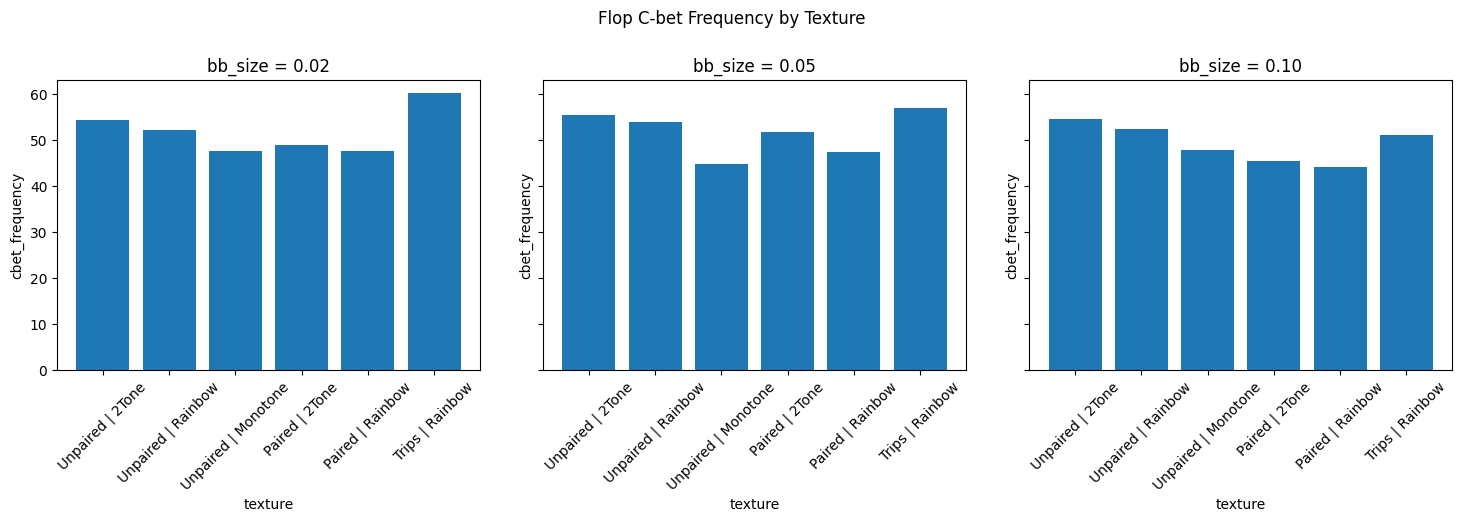

In [ ]:
# Visualize the distribution of cbet frequencies across different textures and bet sizes using bar charts

texture_order = [
    "Unpaired | 2Tone",
    "Unpaired | Rainbow",
    "Unpaired | Monotone",
    "Paired | 2Tone",
    "Paired | Rainbow",
    "Trips | Rainbow",
]

plot_df = (
    strategy_agg
    .groupby(["bb_size", "texture"], as_index=False)
    .agg(
        cbet_opportunities=("cbet_opportunities", "sum"),
        cbets=("cbets", "sum"),
    )
)

plot_df["cbet_frequency"] = plot_df["cbets"] / plot_df["cbet_opportunities"] * 100

stakes = sorted(plot_df["bb_size"].unique())

fig, axes = plt.subplots(1, len(stakes), figsize=(18, 5), sharey=True)

for ax, stake in zip(axes, stakes):
    sub = (
        plot_df[plot_df["bb_size"] == stake]
        .set_index("texture")
        .reindex(texture_order)
        .reset_index()
    )

    ax.bar(sub["texture"], sub["cbet_frequency"])
    ax.set_title(f"bb_size = {stake:.2f}")
    ax.set_xlabel("texture")
    ax.set_ylabel("cbet_frequency")
    ax.tick_params(axis="x", rotation=45)

fig.suptitle("Flop C-bet Frequency by Texture", y=1.02)
fig.subplots_adjust(wspace=0.15, bottom=0.30)
plt.show()

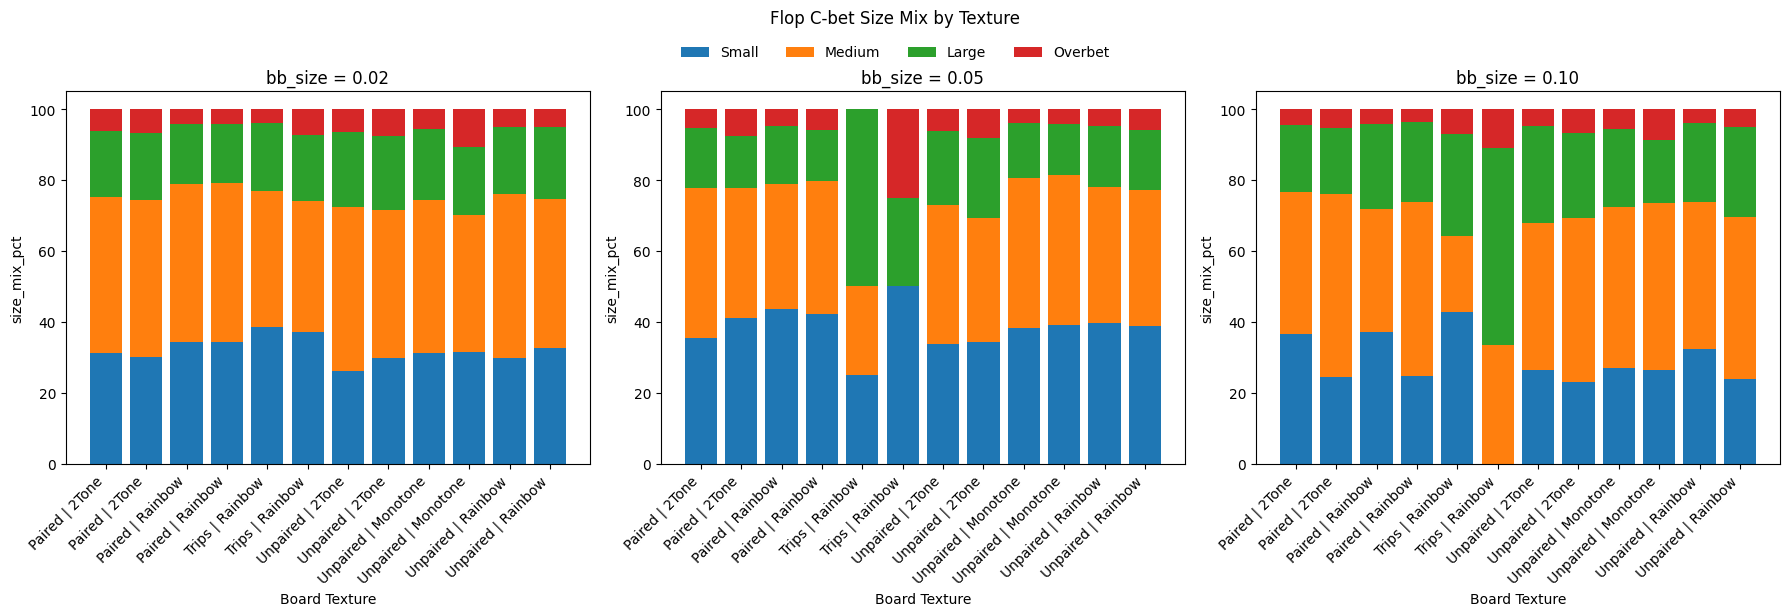

In [73]:
# Visualize the distribution of cbet frequencies across different textures and bet sizes using stacked bar charts to show size mix

fig, axes = plt.subplots(1, len(stakes), figsize=(18, 6), sharey=False)

for ax, stake in zip(axes, stakes):
    sub = strategy_agg[strategy_agg["bb_size"] == stake].copy()
    # sub = sub.sort_values("cbet_frequency", ascending=False)

    x = np.arange(len(sub))
    small   = sub["small_pct"]
    medium  = sub["medium_pct"]
    large   = sub["large_pct"]
    overbet = sub["overbet_pct"]

    ax.bar(x, small, label="Small")
    ax.bar(x, medium, bottom=small, label="Medium")
    ax.bar(x, large, bottom=small + medium, label="Large")
    ax.bar(x, overbet, bottom=small + medium + large, label="Overbet")

    ax.set_title(f"bb_size = {stake:.2f}")
    ax.set_xlabel("Board Texture")
    ax.set_ylabel("size_mix_pct")
    ax.set_xticks(x)
    ax.set_xticklabels(sub["texture"], rotation=45, ha="right")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.98), ncol=4, frameon=False)
fig.suptitle("Flop C-bet Size Mix by Texture", y=1.02)
fig.subplots_adjust(wspace=0.15, bottom=0.30, top=0.72)
plt.tight_layout()
plt.show()